<a href="https://colab.research.google.com/github/truth-breaker/DATA-SCIENCE/blob/main/CKD_Prediction_with_K_Nearest_Neighbors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection  import train_test_split
import numpy as np


In [ ]:
'''
Purpose: The goal is to classify future patients as having CKD or not based on their blood test results.

Information: You're learning how to use attributes (like glucose and hemoglobin levels) to predict the class (CKD or not CKD) of new data points.

Why K-NN: K-NN is used because it is a simple and effective method for classification. It works by finding the nearest neighbors to a new data point and using their classes to make a prediction. This helps in making accurate predictions based on the patterns observed in the training data.
'''

In [66]:
ckd_data = pd.read_csv("ckd.csv")

In [67]:
ckd_data.head()

,Age,Blood Pressure,Specific Gravity,Albumin,Sugar,Red Blood Cells,Pus Cell,Pus Cell clumps,Bacteria,Blood Glucose Random,...,Packed Cell Volume,White Blood Cell Count,Red Blood Cell Count,Hypertension,Diabetes Mellitus,Coronary Artery Disease,Appetite,Pedal Edema,Anemia,Class
0,48,70,1.005,4,0,normal,abnormal,present,notpresent,117,...,32,6700,3.9,yes,no,no,poor,yes,yes,1
1,53,90,1.020,2,0,abnormal,abnormal,present,notpresent,70,...,29,12100,3.7,yes,yes,no,poor,no,yes,1
2,63,70,1.010,3,0,abnormal,abnormal,present,notpresent,380,...,32,4500,3.8,yes,yes,no,poor,yes,no,1
3,68,80,1.010,3,2,normal,abnormal,present,present,157,...,16,11000,2.6,yes,yes,yes,poor,yes,no,1
4,61,80,1.015,2,0,abnormal,abnormal,notpresent,notpresent,173,...,24,9200,3.2,yes,yes,yes,poor,yes,yes,1


In [68]:
ckd_data = ckd_data.rename(columns ={"Blood Glucose Random":"Glucose"})

In [69]:
ckd_data.head()

,Age,Blood Pressure,Specific Gravity,Albumin,Sugar,Red Blood Cells,Pus Cell,Pus Cell clumps,Bacteria,Glucose,...,Packed Cell Volume,White Blood Cell Count,Red Blood Cell Count,Hypertension,Diabetes Mellitus,Coronary Artery Disease,Appetite,Pedal Edema,Anemia,Class
0,48,70,1.005,4,0,normal,abnormal,present,notpresent,117,...,32,6700,3.9,yes,no,no,poor,yes,yes,1
1,53,90,1.020,2,0,abnormal,abnormal,present,notpresent,70,...,29,12100,3.7,yes,yes,no,poor,no,yes,1
2,63,70,1.010,3,0,abnormal,abnormal,present,notpresent,380,...,32,4500,3.8,yes,yes,no,poor,yes,no,1
3,68,80,1.010,3,2,normal,abnormal,present,present,157,...,16,11000,2.6,yes,yes,yes,poor,yes,no,1
4,61,80,1.015,2,0,abnormal,abnormal,notpresent,notpresent,173,...,24,9200,3.2,yes,yes,yes,poor,yes,yes,1


In [70]:
ckd_data.shape

(158, 25)

In [71]:
ckd_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      158 non-null    int64  
 1   Blood Pressure           158 non-null    int64  
 2   Specific Gravity         158 non-null    float64
 3   Albumin                  158 non-null    int64  
 4   Sugar                    158 non-null    int64  
 5   Red Blood Cells          158 non-null    object 
 6   Pus Cell                 158 non-null    object 
 7   Pus Cell clumps          158 non-null    object 
 8   Bacteria                 158 non-null    object 
 9   Glucose                  158 non-null    int64  
 10  Blood Urea               158 non-null    int64  
 11  Serum Creatinine         158 non-null    float64
 12  Sodium                   158 non-null    int64  
 13  Potassium                158 non-null    float64
 14  Hemoglobin               1

In [72]:
ckd_data.isna().sum()

,0
Age,0
Blood Pressure,0
Specific Gravity,0
Albumin,0
Sugar,0
Red Blood Cells,0
Pus Cell,0
Pus Cell clumps,0
Bacteria,0
Glucose,0


In [73]:
ckd_data['Class'].value_counts(normalize = True)

,proportion
Class,
0,0.727848
1,0.272152


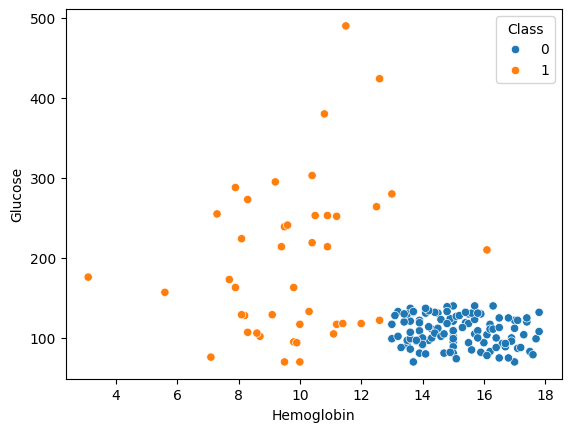

In [74]:
#Class 1 represents has CKD and Class 0 = Has NO CKD
sn.scatterplot(x="Hemoglobin", y = "Glucose", data = ckd_data, hue = "Class")
plt.show()

<Axes: xlabel='White Blood Cell Count', ylabel='Glucose'>

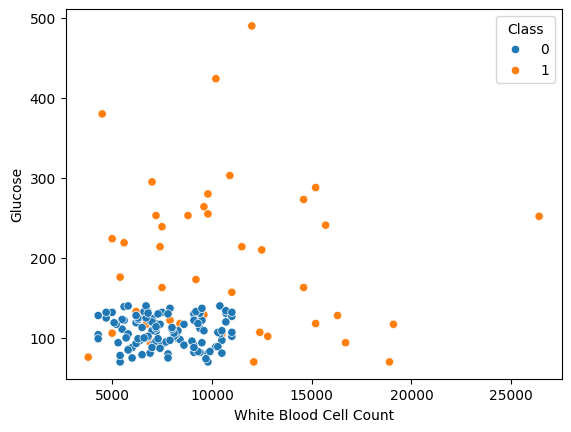

In [75]:
sn.scatterplot(x = "White Blood Cell Count", y = "Glucose", data = ckd_data, hue = "Class")

In [76]:
#Isolating the y var, (Outcome, Target, dependent/Variable we want to predict)
y = ckd_data["Class"]
y.head()

,Class
0,1
1,1
2,1
3,1
4,1


In [107]:
#Isolated the X variable (Features, Indepednent variable, Variables used to predict Y)
X = ckd_data.drop(columns= 'Class')
X.head()
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      158 non-null    int64  
 1   Blood Pressure           158 non-null    int64  
 2   Specific Gravity         158 non-null    float64
 3   Albumin                  158 non-null    int64  
 4   Sugar                    158 non-null    int64  
 5   Red Blood Cells          158 non-null    object 
 6   Pus Cell                 158 non-null    object 
 7   Pus Cell clumps          158 non-null    object 
 8   Bacteria                 158 non-null    object 
 9   Glucose                  158 non-null    int64  
 10  Blood Urea               158 non-null    int64  
 11  Serum Creatinine         158 non-null    float64
 12  Sodium                   158 non-null    int64  
 13  Potassium                158 non-null    float64
 14  Hemoglobin               1

In [96]:
#Selecting X variables that are numeric( int & float data types)


In [108]:

X = X[["Age","Blood Pressure", "Specific Gravity", "Albumin", "Sugar", "Glucose","Blood Urea", "Serum Creatinine", "Sodium","Potassium", "Hemoglobin", "Packed Cell Volume","White Blood Cell Count","Red Blood Cell Count" ]]
X.head()

,Age,Blood Pressure,Specific Gravity,Albumin,Sugar,Glucose,Blood Urea,Serum Creatinine,Sodium,Potassium,Hemoglobin,Packed Cell Volume,White Blood Cell Count,Red Blood Cell Count
0,48,70,1.005,4,0,117,56,3.8,111,2.5,11.2,32,6700,3.9
1,53,90,1.020,2,0,70,107,7.2,114,3.7,9.5,29,12100,3.7
2,63,70,1.010,3,0,380,60,2.7,131,4.2,10.8,32,4500,3.8
3,68,80,1.010,3,2,157,90,4.1,130,6.4,5.6,16,11000,2.6
4,61,80,1.015,2,0,173,148,3.9,135,5.2,7.7,24,9200,3.2


In [109]:
# 75% of the data to the training variables (x_train and y_train) and 25% to the testing variables (x_test and y_test).
#This ensures that x_train and y_train have more data for training the model.
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = .25, random_state = 0)

In [111]:
X_train.head()

,Age,Blood Pressure,Specific Gravity,Albumin,Sugar,Glucose,Blood Urea,Serum Creatinine,Sodium,Potassium,Hemoglobin,Packed Cell Volume,White Blood Cell Count,Red Blood Cell Count
27,21,90,1.010,4,0,107,40,1.7,125,3.5,8.3,23,12400,3.9
111,43,60,1.025,0,0,108,25,1.0,144,5.0,17.8,43,7200,5.5
110,22,60,1.025,0,0,97,18,1.2,138,4.3,13.5,42,7900,6.4
85,43,80,1.025,0,0,81,46,0.6,135,4.9,13.9,48,6900,4.9
18,52,90,1.015,4,3,224,166,5.6,133,47.0,8.1,23,5000,2.9


In [112]:
X_test.head()

,Age,Blood Pressure,Specific Gravity,Albumin,Sugar,Glucose,Blood Urea,Serum Creatinine,Sodium,Potassium,Hemoglobin,Packed Cell Volume,White Blood Cell Count,Red Blood Cell Count
7,73,70,1.005,0,0,70,32,0.9,125,4.0,10.0,29,18900,3.5
44,23,80,1.025,0,0,70,36,1.0,150,4.6,17.0,52,9800,5.0
113,29,80,1.020,0,0,83,49,0.9,139,3.3,17.5,40,9900,4.7
120,47,60,1.020,0,0,117,22,1.2,138,3.5,13.0,45,5200,5.6
63,30,80,1.025,0,0,96,25,0.5,144,4.8,13.8,42,9000,4.5


In [113]:
y_train.head()

,Class
27,1
111,0
110,0
85,0
18,1


In [114]:
y_test.head()

,Class
7,1
44,0
113,0
120,0
63,0


In [115]:
X_train.shape,X_test.shape, y_train.shape, y_test.shape

((118, 14), (40, 14), (118,), (40,))

In [117]:
'''
KNeighborsClassifier- creates a classifier that predicts the class
of a data point by looking at its nearest neighbors.
Look at the 3 closest points (neighbors) in the training set.

The new point gets classified as the majority class among those 3 neighbors.
EX: So if 2 neighbors are class “1” and 1 neighbor is class “0”, then the prediction is class 1 (Has CKD).
knn = ... → creates the KNN model, but it’s not trained yet.
'''
knn = KNeighborsClassifier(n_neighbors= 3)

In [118]:
#train the model
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [123]:
#make predictions
pred_train = knn.predict(X_train)

In [120]:
'''
What it does: Calculates the accuracy of the model on the training data.

Accuracy = (number of correct predictions ÷ total samples).

Basically, it checks how well the model predicts the data it already saw.
'''
knn.score(X_train, y_train)

0.864406779661017

In [121]:
#What it does: Predicts the labels for the test data (x_test).
#These are the model’s guesses for the unseen data.
pred_test = knn.predict(X_test)

In [122]:
pred_test

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [125]:
y_test

,Class
7,1
44,0
113,0
120,0
63,0
122,0
121,0
139,0
109,0
92,0


In [126]:
'''
What it does: Calculates the accuracy on the test set.
This is the most important score → it tells us how well
the model generalizes to unseen data.
'''
knn.score(X_test, y_test)

0.85